# 04 — Gene-subset cosine similarity experiment

Motivated by the observation that using all 5,054 shared genes produces weak, low-margin
assignments, this notebook tests whether restricting the cosine comparison to a focused
subset of discriminative genes improves segmentation-quality assessment.

The key reframe: cosine similarity here is not the end goal — it is a *proxy* for whether
the cell's transcript profile, as shaped by the Cellpose segmentation, is biologically
coherent.  A low or ambiguous similarity score suggests the segmentation may have captured
the wrong transcript mix.  A focused gene subset strips away the noise from housekeeping
and non-discriminative genes, making that signal cleaner.

Two selection strategies are implemented and run back-to-back:

- **marker_panel** — 21 canonical cell-type markers present in the shared Xenium/scRNA space.
- **top_reference_variance** — the top N most variable genes across the scRNA-seq prototypes
  (data-driven; no prior biology required).

**Inputs**
- `outputs/prototypes_normalized.csv`
- `outputs/cell_expression_aligned.csv`
- `outputs/shared_genes.txt`
- `outputs/cell_type_predictions.csv`
- `outputs/cosine_similarity_matrix.csv`

**Outputs** (separate files per mode, nothing from NB03 is overwritten)
- `outputs/gene_subset_{mode}.txt` — selected genes
- `outputs/gene_subset_summary_{mode}.csv` — subset statistics
- `outputs/cosine_similarity_matrix_{mode}.csv` — subset similarity matrix
- `outputs/cell_type_predictions_{mode}.csv` — subset predictions with signal flag
- `outputs/regular_vs_{mode}_predictions.csv` — side-by-side comparison

Both mode outputs feed into NB05 where they are used as the confidence criterion for the
ablation / re-segmentation loop.


## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity

## Config

In [2]:
PROJECT_ROOT = Path("..")
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PROTOTYPES_PATH        = OUTPUT_DIR / "prototypes_normalized.csv"
CELL_EXPR_PATH         = OUTPUT_DIR / "cell_expression_aligned.csv"
SHARED_GENES_PATH      = OUTPUT_DIR / "shared_genes.txt"
BASELINE_PREDICTIONS_PATH = OUTPUT_DIR / "cell_type_predictions.csv"
BASELINE_SIM_MATRIX_PATH  = OUTPUT_DIR / "cosine_similarity_matrix.csv"

# Subset strategy
# "marker_panel"          → canonical markers present in the Xenium/scRNA shared space.
# "top_reference_variance" → top N most variable genes across the scRNA-seq prototypes.
#
# Both modes are run sequentially below so results can be compared side-by-side.
# To run only one mode, comment out the other entry in MODES_TO_RUN.
MODES_TO_RUN = ["marker_panel", "top_reference_variance"]

TOP_N_REFERENCE_GENES = 100   # used only by top_reference_variance mode
HEATMAP_N_CELLS = 50

# Canonical marker genes per cell type.
# These encode prior biological knowledge and are used by the marker_panel mode.
# Genes missing from the shared Xenium space are silently skipped during selection.
MARKER_GENES = {
    "fibroblast":             ["DCN", "LUM", "PDGFRA", "COL1A1", "COL1A2"],
    "myofibroblast":          ["ACTA2", "TAGLN", "MYL9", "COL3A1"],
    "endothelial":            ["PECAM1", "VWF", "KDR", "RAMP2", "ENG"],
    "pericyte":               ["RGS5", "PDGFRB", "MCAM", "CSPG4"],
    "vascular_smooth_muscle": ["ACTA2", "MYH11", "TAGLN", "MYLK"],
    "cycling":                ["MKI67", "TOP2A", "UBE2C", "CENPF"],
    "immune":                 ["PTPRC", "CD3D", "CD3E", "MS4A1", "LYZ"],
    "epithelial":             ["EPCAM", "KRT8", "KRT18", "KRT19"],
}

## Helper functions

In [3]:
def require_file(path: Path, description: str):
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {description}: {path}\n"
            "Run the earlier notebooks first or check the configured paths."
        )


def savefig(name: str, dpi: int = 300):
    path = FIGURES_DIR / name
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved → {path}")


def normalize_rows(df: pd.DataFrame) -> pd.DataFrame:
    """L2-normalise every row; rows with zero norm are left as-is (all zeros)."""
    values = df.values.astype(float)
    norms = np.linalg.norm(values, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return pd.DataFrame(values / norms, index=df.index, columns=df.columns)


def compute_predictions(sim_df: pd.DataFrame) -> pd.DataFrame:
    """Derive per-cell type assignment and margin from a similarity matrix."""
    preds = pd.DataFrame(index=sim_df.index)
    preds["predicted_cell_type"] = sim_df.idxmax(axis=1)
    preds["best_similarity"]     = sim_df.max(axis=1)
    sorted_scores = np.sort(sim_df.values, axis=1)
    preds["margin"] = sorted_scores[:, -1] - sorted_scores[:, -2]
    return preds


def select_genes(mode: str, shared_genes: list, prototypes: pd.DataFrame) -> list:
    """
    Return the gene list for a given mode.

    marker_panel
        Union of canonical MARKER_GENES entries that are present in shared_genes.
        These genes are chosen for prior biological relevance, not statistical criteria.

    top_reference_variance
        Top-N genes ranked by variance across prototype (cell-type mean) profiles.
        A gene that varies a lot between prototypes is likely discriminative regardless
        of which specific cell types are present.
    """
    if mode == "marker_panel":
        return sorted({
            gene
            for genes in MARKER_GENES.values()
            for gene in genes
            if gene in shared_genes
        })
    elif mode == "top_reference_variance":
        reference_variance = prototypes.var(axis=0).sort_values(ascending=False)
        return reference_variance.head(TOP_N_REFERENCE_GENES).index.tolist()
    else:
        raise ValueError(f"Unsupported mode: {mode!r}")


def mode_tag(mode: str) -> str:
    """Short string used as a filename suffix for a given mode."""
    if mode == "marker_panel":
        return "marker_subset"
    elif mode == "top_reference_variance":
        return f"top{TOP_N_REFERENCE_GENES}_variance"
    raise ValueError(f"Unknown mode: {mode!r}")

## 1 · Load shared inputs

In [4]:
require_file(PROTOTYPES_PATH,           "normalized prototypes")
require_file(CELL_EXPR_PATH,            "cell expression matrix")
require_file(SHARED_GENES_PATH,         "shared genes list")
require_file(BASELINE_PREDICTIONS_PATH, "baseline predictions")
require_file(BASELINE_SIM_MATRIX_PATH,  "baseline similarity matrix")

with open(SHARED_GENES_PATH) as f:
    shared_genes = [line.strip() for line in f if line.strip()]

prototypes            = pd.read_csv(PROTOTYPES_PATH,           index_col=0)
cells                 = pd.read_csv(CELL_EXPR_PATH,            index_col=0)
baseline_predictions  = pd.read_csv(BASELINE_PREDICTIONS_PATH, index_col=0)
baseline_sim          = pd.read_csv(BASELINE_SIM_MATRIX_PATH,  index_col=0)

# Align columns to the shared gene order so array operations are safe.
prototypes = prototypes.reindex(columns=shared_genes, fill_value=0)
cells      = cells.reindex(columns=shared_genes,      fill_value=0)

assert list(prototypes.columns) == shared_genes, "Prototype gene order mismatch."
assert list(cells.columns)      == shared_genes, "Cell gene order mismatch."
assert list(baseline_predictions.index) == list(cells.index), "Cell index mismatch (predictions)."
assert list(baseline_sim.index)         == list(cells.index), "Cell index mismatch (similarity matrix)."

print("Cells:                   ", cells.shape)
print("Prototypes:              ", prototypes.shape)
print("Baseline predictions:    ", baseline_predictions.shape)
print("Baseline similarity matrix:", baseline_sim.shape)
print("Shared genes:            ", len(shared_genes))

Cells:                    (82, 5054)
Prototypes:               (8, 5054)
Baseline predictions:     (82, 2)
Baseline similarity matrix: (82, 8)
Shared genes:             5054


## 2 · Run gene-subset experiments

Both modes (marker panel and top-variance) are executed in a single loop.
Each mode produces its own output files; nothing from NB03 is overwritten.


In [5]:
# Collect results across modes for the comparison plot at the end
all_mode_results = {}

for mode in MODES_TO_RUN:
    tag = mode_tag(mode)
    print(f"\n{'='*60}")
    print(f"Mode: {mode}  (tag: {tag})")
    print(f"{'='*60}")

    # Select genes
    subset_genes = select_genes(mode, shared_genes, prototypes)

    if len(subset_genes) < 5:
        raise ValueError(
            f"Only {len(subset_genes)} genes selected for mode {mode!r}. "
            "Choose a larger or different subset."
        )

    # Marker-panel: also report how many of the canonical markers were missing.
    marker_genes_present = sorted({
        g for genes in MARKER_GENES.values() for g in genes if g in shared_genes
    })
    marker_genes_missing = sorted({
        g for genes in MARKER_GENES.values() for g in genes if g not in shared_genes
    })

    # Save gene list
    gene_list_path = OUTPUT_DIR / f"gene_subset_{tag}.txt"
    with open(gene_list_path, "w") as fh:
        for gene in subset_genes:
            fh.write(f"{gene}\n")

    # Save summary
    summary_path = OUTPUT_DIR / f"gene_subset_summary_{tag}.csv"
    pd.DataFrame([
        {"metric": "gene_subset_mode",          "value": tag},
        {"metric": "n_subset_genes",             "value": len(subset_genes)},
        {"metric": "n_shared_genes",             "value": len(shared_genes)},
        {"metric": "fraction_of_shared_genes",   "value": len(subset_genes) / len(shared_genes)},
        {"metric": "n_marker_genes_present",     "value": len(marker_genes_present)},
        {"metric": "n_marker_genes_missing",     "value": len(marker_genes_missing)},
    ]).to_csv(summary_path, index=False)

    print(f"  Genes selected:         {len(subset_genes)}")
    print(f"  Genes selected (first): {subset_genes[:10]}")
    if mode == "marker_panel" and marker_genes_missing:
        print(f"  Canonical genes missing from Xenium panel: {marker_genes_missing}")
    print(f"  Saved gene list → {gene_list_path}")

    # Subset expression matrices and normalise
    cells_subset      = cells.reindex(columns=subset_genes, fill_value=0)
    prototypes_subset = prototypes.reindex(columns=subset_genes, fill_value=0)

    # Cells with zero total counts in the subset cannot be assigned, likely reflect segmentation noise or absence of these transcripts in that region.
    subset_signal_sum  = cells_subset.sum(axis=1)
    valid_subset_cells = subset_signal_sum > 0
    n_zero_signal      = int((~valid_subset_cells).sum())

    if n_zero_signal:
        print(
            f"  Warning: {n_zero_signal} cells have zero counts in this subset. "
            "They will be marked as 'unassigned_subset_no_signal'. "
            "This is biologically informative: those cells may lack discriminative "
            "marker transcripts, possibly due to sparse capture or segmentation errors."
        )

    # Normalise only the valid cells; prototypes are always normalised
    cells_subset_valid    = cells_subset.loc[valid_subset_cells].copy()
    cells_subset_norm     = normalize_rows(cells_subset_valid)
    prototypes_subset_norm = normalize_rows(prototypes_subset)

    # Compute cosine similarity on the subset
    subset_sim_valid = pd.DataFrame(
        cosine_similarity(cells_subset_norm.values, prototypes_subset_norm.values),
        index=cells_subset_norm.index,
        columns=prototypes_subset_norm.index,
    )
    subset_predictions_valid = compute_predictions(subset_sim_valid)

    # Re-index to full cell list; NaN for cells with no subset signal.
    subset_sim = pd.DataFrame(
        np.nan,
        index=cells.index,
        columns=prototypes_subset_norm.index,
    )
    subset_sim.loc[valid_subset_cells] = subset_sim_valid

    subset_predictions = pd.DataFrame(index=cells.index)
    subset_predictions["predicted_cell_type"] = "unassigned_subset_no_signal"
    subset_predictions["best_similarity"]      = np.nan
    subset_predictions["margin"]               = np.nan
    subset_predictions["subset_signal_sum"]    = subset_signal_sum

    subset_predictions.loc[
        valid_subset_cells,
        ["predicted_cell_type", "best_similarity", "margin"]
    ] = subset_predictions_valid[["predicted_cell_type", "best_similarity", "margin"]]

    # Save outputs
    sim_matrix_path  = OUTPUT_DIR / f"cosine_similarity_matrix_{tag}.csv"
    predictions_path = OUTPUT_DIR / f"cell_type_predictions_{tag}.csv"
    subset_sim.to_csv(sim_matrix_path)
    subset_predictions.to_csv(predictions_path)

    print(f"  Cells with usable signal: {int(valid_subset_cells.sum())} / {len(valid_subset_cells)}")
    print(f"  Median best similarity:   {subset_predictions['best_similarity'].median():.3f}")
    print(f"  Median margin:            {subset_predictions['margin'].median():.6f}")
    print(f"  Saved similarity matrix  → {sim_matrix_path}")
    print(f"  Saved predictions        → {predictions_path}")

    # Side-by-side comparison with the full-gene baseline
    baseline_sorted_scores = np.sort(baseline_sim.values, axis=1)
    baseline_margin        = baseline_sorted_scores[:, -1] - baseline_sorted_scores[:, -2]

    comparison = pd.DataFrame({
        "baseline_type":   baseline_predictions["predicted_cell_type"],
        "baseline_score":  baseline_predictions["best_similarity"],
        "baseline_margin": baseline_margin,
        "subset_type":     subset_predictions["predicted_cell_type"],
        "subset_score":    subset_predictions["best_similarity"],
        "subset_margin":   subset_predictions["margin"],
        "subset_signal_sum": subset_predictions["subset_signal_sum"],
    }, index=cells.index)

    comparison["subset_has_signal"]         = comparison["subset_score"].notna()
    comparison["type_changed"]              = comparison["baseline_type"] != comparison["subset_type"]
    comparison["type_changed_among_scored"] = comparison["subset_has_signal"] & comparison["type_changed"]
    comparison["score_delta"]               = comparison["subset_score"] - comparison["baseline_score"]
    comparison["margin_delta"]              = comparison["subset_margin"] - comparison["baseline_margin"]

    comparison_path = OUTPUT_DIR / f"regular_vs_{tag}_predictions.csv"
    comparison.to_csv(comparison_path)

    scored = comparison[comparison["subset_has_signal"]]
    print(f"  Cells with changed type (among scored): "
          f"{int(comparison['type_changed_among_scored'].sum())} / {int(comparison['subset_has_signal'].sum())}")
    print(f"  Mean score delta (scored):   {scored['score_delta'].mean():.4f}")
    print(f"  Median margin delta (scored): {scored['margin_delta'].median():.6f}")
    print(f"  Saved comparison → {comparison_path}")

    # Stash for cross-mode plots.
    all_mode_results[tag] = {
        "mode": mode,
        "tag": tag,
        "subset_genes": subset_genes,
        "subset_sim": subset_sim,
        "subset_predictions": subset_predictions,
        "comparison": comparison,
        "valid_subset_cells": valid_subset_cells,
    }


Mode: marker_panel  (tag: marker_subset)
  Genes selected:         21
  Genes selected (first): ['CD3D', 'CD3E', 'CENPF', 'CSPG4', 'DCN', 'ENG', 'EPCAM', 'KDR', 'LUM', 'MCAM']
  Canonical genes missing from Xenium panel: ['ACTA2', 'COL1A1', 'COL1A2', 'COL3A1', 'KRT18', 'KRT19', 'KRT8', 'LYZ', 'PTPRC', 'RAMP2', 'TAGLN', 'VWF']
  Saved gene list → ../outputs/gene_subset_marker_subset.txt
  Cells with usable signal: 31 / 82
  Median best similarity:   0.320
  Median margin:            0.034326
  Saved similarity matrix  → ../outputs/cosine_similarity_matrix_marker_subset.csv
  Saved predictions        → ../outputs/cell_type_predictions_marker_subset.csv
  Cells with changed type (among scored): 26 / 31
  Mean score delta (scored):   0.2517
  Median margin delta (scored): 0.033924
  Saved comparison → ../outputs/regular_vs_marker_subset_predictions.csv

Mode: top_reference_variance  (tag: top100_variance)
  Genes selected:         100
  Genes selected (first): ['MYL9', 'DCN', 'LUM', 'RGS5

## 3 · Per-mode comparison plots

Saved → ../outputs/figures/gene_subset_comparison_marker_subset.png


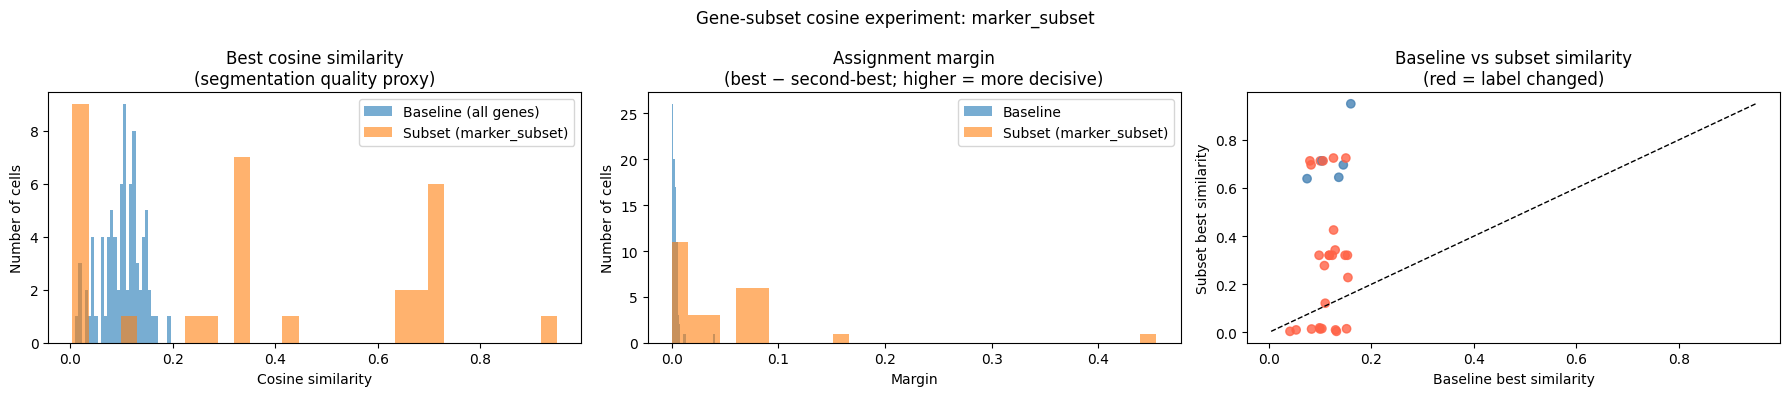

Saved → ../outputs/figures/similarity_heatmap_marker_subset.png


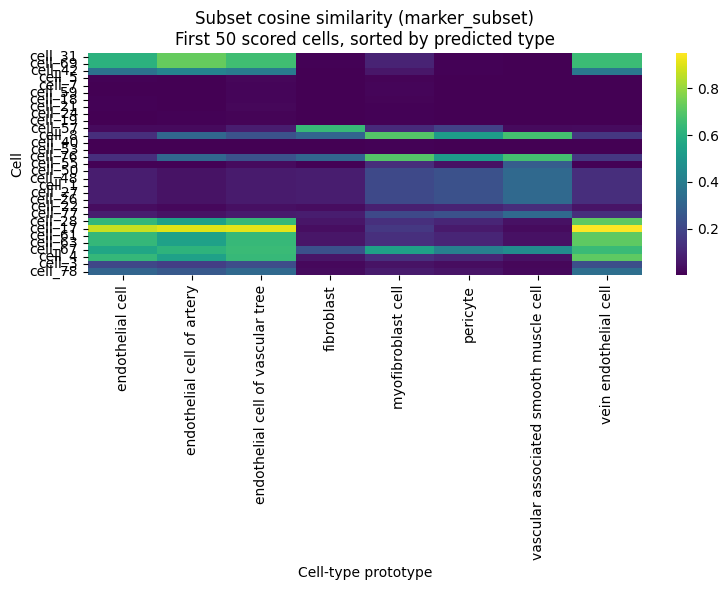

Saved → ../outputs/figures/gene_subset_comparison_top100_variance.png


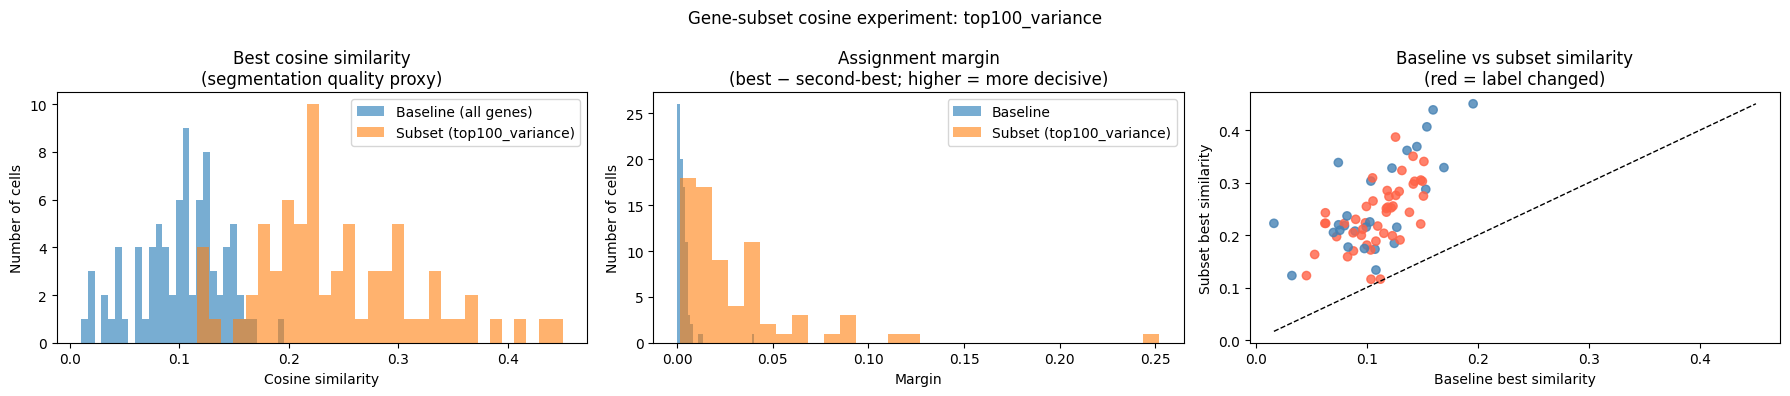

Saved → ../outputs/figures/similarity_heatmap_top100_variance.png


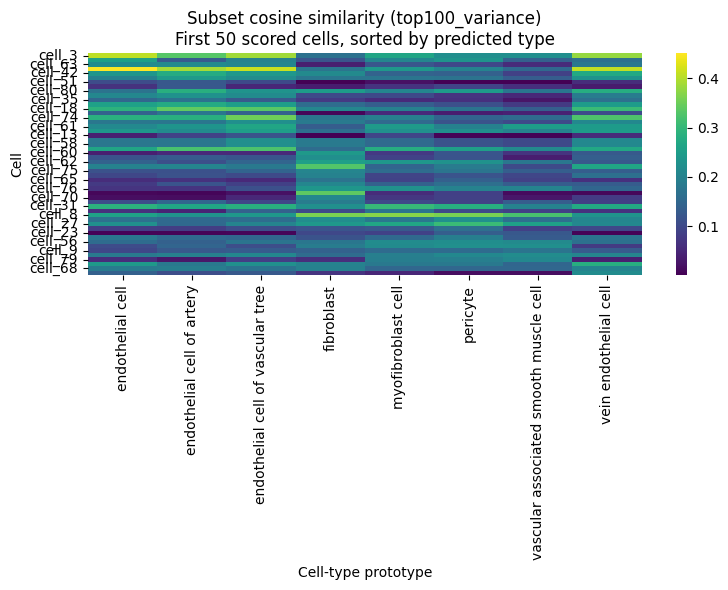

In [6]:
for tag, res in all_mode_results.items():
    comparison = res["comparison"]
    scored = comparison[comparison["subset_has_signal"]]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # Score distribution overlay.
    axes[0].hist(comparison["baseline_score"],        bins=30, alpha=0.6, label="Baseline (all genes)")
    axes[0].hist(comparison["subset_score"].dropna(), bins=30, alpha=0.6, label=f"Subset ({tag})")
    axes[0].set_title("Best cosine similarity\n(segmentation quality proxy)")
    axes[0].set_xlabel("Cosine similarity")
    axes[0].set_ylabel("Number of cells")
    axes[0].legend()

    # Margin distribution overlay.
    axes[1].hist(comparison["baseline_margin"],        bins=30, alpha=0.6, label="Baseline")
    axes[1].hist(comparison["subset_margin"].dropna(), bins=30, alpha=0.6, label=f"Subset ({tag})")
    axes[1].set_title("Assignment margin\n(best − second-best; higher = more decisive)")
    axes[1].set_xlabel("Margin")
    axes[1].set_ylabel("Number of cells")
    axes[1].legend()

    # Scatter: baseline score vs subset score, coloured by type change.
    axes[2].scatter(
        scored["baseline_score"],
        scored["subset_score"],
        c=scored["type_changed"].map({False: "steelblue", True: "tomato"}),
        alpha=0.8,
    )
    lo = min(scored["baseline_score"].min(), scored["subset_score"].min())
    hi = max(scored["baseline_score"].max(), scored["subset_score"].max())
    axes[2].plot([lo, hi], [lo, hi], linestyle="--", color="black", linewidth=1)
    axes[2].set_title("Baseline vs subset similarity\n(red = label changed)")
    axes[2].set_xlabel("Baseline best similarity")
    axes[2].set_ylabel("Subset best similarity")

    plt.suptitle(f"Gene-subset cosine experiment: {tag}", fontsize=12)
    plt.tight_layout()
    savefig(f"gene_subset_comparison_{tag}.png")
    plt.show()

    # Heatmap: subset similarity for top N scored cells sorted by type.
    subset_scored = res["subset_predictions"][
        res["subset_predictions"]["best_similarity"].notna()
    ].copy()
    sorted_idx   = subset_scored.sort_values("predicted_cell_type").index
    heatmap_data = res["subset_sim"].loc[sorted_idx].iloc[:HEATMAP_N_CELLS]

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(heatmap_data, cmap="viridis", ax=ax)
    ax.set_title(f"Subset cosine similarity ({tag})\nFirst {HEATMAP_N_CELLS} scored cells, sorted by predicted type")
    ax.set_xlabel("Cell-type prototype")
    ax.set_ylabel("Cell")
    plt.tight_layout()
    savefig(f"similarity_heatmap_{tag}.png")
    plt.show()

## 4 · Cross-mode summary

In [7]:
print("\nCross-mode summary")
print("=" * 60)

summary_rows = []
for tag, res in all_mode_results.items():
    comparison = res["comparison"]
    scored     = comparison[comparison["subset_has_signal"]]
    summary_rows.append({
        "mode":                       tag,
        "n_subset_genes":             len(res["subset_genes"]),
        "cells_with_signal":          int(res["valid_subset_cells"].sum()),
        "cells_total":                len(comparison),
        "mean_baseline_similarity":   comparison["baseline_score"].mean().round(4),
        "mean_subset_similarity":     scored["subset_score"].mean().round(4),
        "mean_margin_baseline":       comparison["baseline_margin"].mean().round(6),
        "mean_margin_subset":         scored["subset_margin"].mean().round(6),
        "cells_changed_type_scored":  int(comparison["type_changed_among_scored"].sum()),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

summary_df.to_csv(OUTPUT_DIR / "gene_subset_mode_comparison.csv", index=False)
print("Saved cross-mode summary → outputs/gene_subset_mode_comparison.csv")

print("\nBaseline vs. subset cell-type distributions (marker_subset):")
if "marker_subset" in all_mode_results:
    cmp = all_mode_results["marker_subset"]["comparison"]
    print(pd.crosstab(cmp["baseline_type"], cmp["subset_type"]))


Cross-mode summary


,mode,n_subset_genes,cells_with_signal,cells_total,mean_baseline_similarity,mean_subset_similarity,mean_margin_baseline,mean_margin_subset,cells_changed_type_scored
0,marker_subset,21,31,82,0.1009,0.3661,0.003193,0.057698,26
1,top100_variance,100,72,82,0.1009,0.2455,0.003193,0.030605,46


Saved cross-mode summary → outputs/gene_subset_mode_comparison.csv

Baseline vs. subset cell-type distributions (marker_subset):
subset_type                             endothelial cell of artery  \
baseline_type                                                        
endothelial cell                                                 2   
endothelial cell of artery                                       0   
endothelial cell of vascular tree                                0   
fibroblast                                                       1   
myofibroblast cell                                               0   
pericyte                                                         0   
vascular associated smooth muscle cell                           0   
vein endothelial cell                                            0   

subset_type                             endothelial cell of vascular tree  \
baseline_type                                                               
endothelial cell

## Interpretation checklist

When reviewing these results, focus on:

1. **Score and margin increase**: both should rise in the subset run for scored cells.
   A large jump supports the hypothesis that the full 5,054-gene space dilutes the
   discriminative signal.

2. **Coverage (cells with signal)**: the marker_panel subset is strict, only 21 genes,
   so many cells may show zero counts.  The top-variance subset covers 100 genes and
   should score more cells; if it also improves margins, it is the better criterion
   to feed into the ablation study in NB05.

3. **Label stability**: large numbers of changed labels among scored cells suggests the
   full-gene embedding was genuinely noisy. Stable labels suggest the gene subset
   confirms the baseline assignments.

4. **Cells with no subset signal**: these are the cells most likely to have been
   poorly segmented (too few transcripts captured) and should be prioritised for
   re-segmentation in NB05.

The outputs of this notebook — particularly `cell_type_predictions_{tag}.csv` and
`cosine_similarity_matrix_{tag}.csv`, are read by NB05 to drive the segmentation
correction loop with a subset-based confidence criterion.
